In [110]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## System Dynamics

In [111]:
def chua(t, state, a, b, alpha, beta, gamma):
    x, y, z = state
    dstate = np.zeros_like(state)
    fx = b*x + 0.5*(a-b)*(np.abs(x+1)-np.abs(x-1))
    dstate[0] = alpha*(y-x-fx)
    dstate[1] = x-y+z
    dstate[2] = -beta*y-gamma*z

    return dstate

In [112]:
def chua(t, state, a, b, alpha, beta, gamma):
    x, y, z = state
    dstate = np.zeros_like(state)
    fx = b*x + 0.5*(a-b)*(np.abs(x+1)-np.abs(x-1))
    dstate[0] = alpha*(y-x-fx)
    dstate[1] = x-y+z
    dstate[2] = -beta*y-gamma*z-beta*0.2*np.sin(0.5*x)

    return dstate

## Using RK45 to solve ODE

In [113]:
tspan = [0, 50]
teval = np.arange(tspan[0], tspan[1], 0.01)
# initial_states = [17.67715816276679, 12.931379185960404, 43.91404334248268]
initial_states = [1, 1, 1]
method = 'RK23'

data_chua = solve_ivp(fun=chua, t_span=tspan, y0=initial_states, t_eval=teval, method=method, args=(-1.4325, -0.7831, 10, 19.53, 0.1636))
data_chua = np.vstack((data_chua.t, data_chua.y)).T

## Plot the dataset

In [114]:
def plot_data(data, ax, name):
    N = data.shape[0]
    ax.set_title(name)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    ax.grid(False)

    ax.plot(data[:, 1], data[:, 2], data[:, 3])
    # for i in range(N-1):
    #     ax.plot(data[i:i+2, 1], data[i:i+2, 2], data[i:i+2, 3], color=plt.cm.magma(255*i//N), lw=1.0)

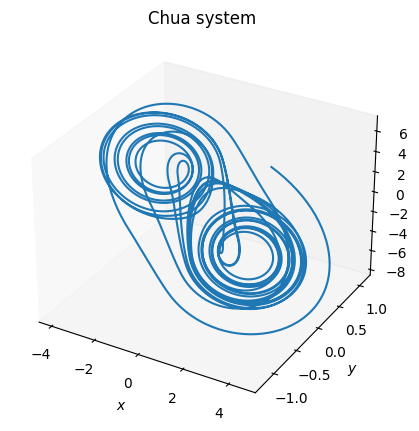

In [115]:
fig = plt.figure(figsize=(18, 5))
ax = fig.add_subplot(111, projection='3d')
plot_data(data=data_chua, ax=ax, name='Chua system')
plt.show()

In [116]:
df1 = pd.DataFrame(data_chua, columns=['t', 'x', 'y', 'z'])
csv_path = '../Dataset/Chua_data.csv'
df1.to_csv(csv_path, index=False)